In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
file_path = "dannie-for-abtest.xlsx"

users = pd.read_excel(file_path, sheet_name="Пользователи")
payments = pd.read_excel(file_path, sheet_name="Платежи")

In [63]:
print("Пользователи:", users.shape)
print("Платежи:", payments.shape)

display(users.head())
display(payments.head())

Пользователи: (1504, 5)
Платежи: (2661, 7)


,user_id,group,age,city,device_type
0,1001,A,31,Москва,ios
1,1002,A,31,Москва,ios
2,1003,A,25,Москва,android
3,1004,A,20,Москва,ios
4,1005,A,34,Москва,ios


,payment_id,user_id,group,step1_opened,step2_entered,step3_confirmed,step4_success
0,5001,1001.0,A,2024-04-16 06:06:00,2024-04-16 06:10:00,NaT,NaT
1,5002,1002.0,A,2024-04-12 07:38:00,2024-04-12 07:41:00,NaT,NaT
2,5003,1003.0,A,2024-04-26 20:03:00,2024-04-26 20:07:00,NaT,NaT
3,5004,1004.0,A,2024-04-09 16:02:00,NaT,NaT,NaT
4,5005,1004.0,A,2024-04-04 03:46:00,2024-04-04 03:54:00,2024-04-04 03:57:00,2024-04-04 04:02:00


In [64]:
print("Пропуски в users:")
display(users.isna().sum())

print("Пропуски в payments:")
display(payments.isna().sum())

print("Дубли user_id:", users["user_id"].duplicated().sum())
print("Дубли payment_id:", payments["payment_id"].duplicated().sum())

print("Группы:", users["group"].value_counts(dropna=False))
print("Возраст:", users["age"].min(), "-", users["age"].max())
print("Устройства:", users["device_type"].value_counts(dropna=False))

Пропуски в users:


user_id        0
group          1
age            0
city           1
device_type    0
dtype: int64

Пропуски в payments:


payment_id            0
user_id               1
group                 0
step1_opened          0
step2_entered       405
step3_confirmed     942
step4_success      1139
dtype: int64

Дубли user_id: 0
Дубли payment_id: 0
Группы: group
A      752
B      751
NaN      1
Name: count, dtype: int64
Возраст: -5 - 150
Устройства: device_type
android    777
ios        727
Name: count, dtype: int64


In [65]:
print("Пользователь без группы:")
display(users[users["group"].isna()])

print("Некорректный возраст:")
display(users[(users["age"] < 18) | (users["age"] > 100)])

print("Пользователь без города:")
display(users[users["city"].isna()])

print("Платёж без user_id:")
display(payments[payments["user_id"].isna()])

Пользователь без группы:


,user_id,group,age,city,device_type
1500,9001,NaN,25,Москва,ios


Некорректный возраст:


,user_id,group,age,city,device_type
1501,9002,A,-5,СПб,android
1502,9003,B,150,Регион,ios


Пользователь без города:


,user_id,group,age,city,device_type
1503,9004,A,30,NaN,android


Платёж без user_id:


,payment_id,user_id,group,step1_opened,step2_entered,step3_confirmed,step4_success
2660,99003,NaN,A,2024-04-12 09:15:00,NaT,NaT,NaT


In [66]:
check_groups = payments.merge(
    users[["user_id", "group"]],
    on="user_id",
    how="left",
    suffixes=("_payment", "_user")
)

group_mismatch = check_groups[
    check_groups["group_payment"] != check_groups["group_user"]
]

display(group_mismatch)

,payment_id,user_id,group_payment,step1_opened,step2_entered,step3_confirmed,step4_success,group_user
2659,99002,1010.0,B,2024-04-08 14:20:00,2024-04-08 14:23:00,2024-04-08 14:28:00,2024-04-08 14:29:00,A
2660,99003,NaN,A,2024-04-12 09:15:00,NaT,NaT,NaT,NaN


In [67]:
invalid_funnel = payments[
    (payments["step2_entered"].notna() & payments["step1_opened"].isna()) |
    (payments["step3_confirmed"].notna() & payments["step2_entered"].isna()) |
    (payments["step4_success"].notna() & payments["step3_confirmed"].isna())
]

print("Некорректных последовательностей:", len(invalid_funnel))
display(invalid_funnel)

Некорректных последовательностей: 0


,payment_id,user_id,group,step1_opened,step2_entered,step3_confirmed,step4_success


In [68]:
# Удаляем пользователей с некорректными данными
users_clean = users[
    users["group"].isin(["A", "B"]) &
    users["age"].between(18, 100)
].copy()

# Удаляем платежи без user_id
payments_clean = payments.dropna(subset=["user_id"]).copy()

# Группу берём из таблицы пользователей
payments_clean = payments_clean.drop(columns="group").merge(
    users_clean[["user_id", "group"]],
    on="user_id",
    how="inner"
)

print("Пользователей после очистки:", len(users_clean))
print("Платежей после очистки:", len(payments_clean))
print()
print(users_clean["group"].value_counts())

Пользователей после очистки: 1501
Платежей после очистки: 2660

group
A    751
B    750
Name: count, dtype: int64


In [69]:
user_funnel = (
    payments_clean
    .groupby(["user_id", "group"])
    .agg(
        step1=("step1_opened", lambda x: x.notna().any()),
        step2=("step2_entered", lambda x: x.notna().any()),
        step3=("step3_confirmed", lambda x: x.notna().any()),
        step4=("step4_success", lambda x: x.notna().any())
    )
    .reset_index()
)

user_funnel.head()

,user_id,group,step1,step2,step3,step4
0,1001.0,A,True,True,False,False
1,1002.0,A,True,True,False,False
2,1003.0,A,True,True,False,False
3,1004.0,A,True,True,True,True
4,1005.0,A,True,True,True,True


In [70]:
funnel = user_funnel.groupby("group")[["step1", "step2", "step3", "step4"]].sum()

funnel["conversion"] = funnel["step4"] / funnel["step1"]

display(funnel)

,step1,step2,step3,step4,conversion
group,,,,,
A,751,672,549,494,0.65779
B,750,707,644,603,0.80400


In [71]:
from statsmodels.stats.proportion import proportions_ztest

success = [603, 494]
nobs = [750, 751]

z_stat, p_value = proportions_ztest(
    count=success,
    nobs=nobs,
    alternative="larger"
)

print(f"z-статистика: {z_stat:.3f}")
print(f"p-value: {p_value:.6f}")

z-статистика: 6.386
p-value: 0.000000


In [72]:
from statsmodels.stats.proportion import confint_proportions_2indep

conv_a = 494 / 751
conv_b = 603 / 750

diff = conv_b - conv_a
relative_uplift = diff / conv_a

ci_low, ci_high = confint_proportions_2indep(
    count1=603,
    nobs1=750,
    count2=494,
    nobs2=751,
    method="wald"
)

print(f"Конверсия A: {conv_a:.2%}")
print(f"Конверсия B: {conv_b:.2%}")
print(f"Абсолютный эффект: {diff:.2%}")
print(f"Относительный uplift: {relative_uplift:.2%}")
print(f"95% ДИ эффекта: [{ci_low:.2%}; {ci_high:.2%}]")

Конверсия A: 65.78%
Конверсия B: 80.40%
Абсолютный эффект: 14.62%
Относительный uplift: 22.23%
95% ДИ эффекта: [10.20%; 19.05%]


In [73]:
step_conversion = pd.DataFrame(index=["A", "B"])

step_conversion["1 → 2"] = funnel["step2"] / funnel["step1"]
step_conversion["2 → 3"] = funnel["step3"] / funnel["step2"]
step_conversion["3 → 4"] = funnel["step4"] / funnel["step3"]
step_conversion["1 → 4"] = funnel["step4"] / funnel["step1"]

display((step_conversion * 100).round(2))

,1 → 2,2 → 3,3 → 4,1 → 4
A,89.48,81.70,89.98,65.78
B,94.27,91.09,93.63,80.40


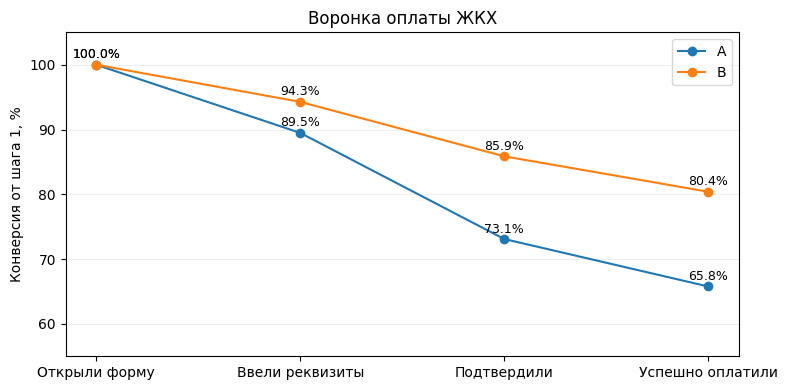

In [74]:
funnel_pct = funnel[["step1", "step2", "step3", "step4"]].div(
    funnel["step1"], axis=0
) * 100

steps = ["Открыли форму", "Ввели реквизиты", "Подтвердили", "Успешно оплатили"]

plt.figure(figsize=(8, 4))

plt.plot(steps, funnel_pct.loc["A"], marker="o", label="A")
plt.plot(steps, funnel_pct.loc["B"], marker="o", label="B")

for group in ["A", "B"]:
    for i, value in enumerate(funnel_pct.loc[group]):
        plt.text(i, value + 1, f"{value:.1f}%", ha="center", fontsize=9)

plt.ylabel("Конверсия от шага 1, %")
plt.title("Воронка оплаты ЖКХ")
plt.ylim(55, 105)
plt.legend()
plt.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.savefig("images/funnel.png", dpi=300, bbox_inches="tight")
plt.show()

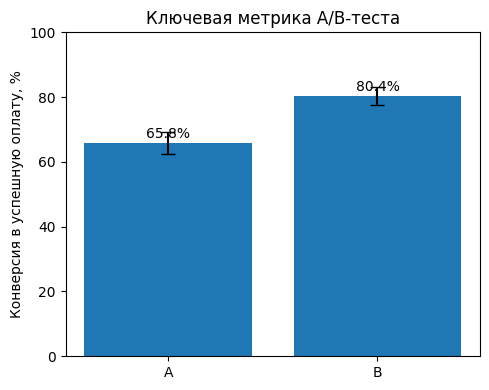

In [75]:
from statsmodels.stats.proportion import proportion_confint

conv = {
    "A": 494 / 751,
    "B": 603 / 750
}

ci_a = proportion_confint(494, 751, alpha=0.05, method="normal")
ci_b = proportion_confint(603, 750, alpha=0.05, method="normal")

groups = ["A", "B"]
values = [conv["A"] * 100, conv["B"] * 100]

errors = [
    [values[0] - ci_a[0] * 100, values[1] - ci_b[0] * 100],
    [ci_a[1] * 100 - values[0], ci_b[1] * 100 - values[1]]
]

plt.figure(figsize=(5, 4))

plt.bar(groups, values, yerr=errors, capsize=5)

for i, value in enumerate(values):
    plt.text(i, value + 1.5, f"{value:.1f}%", ha="center")

plt.ylabel("Конверсия в успешную оплату, %")
plt.title("Ключевая метрика A/B-теста")
plt.ylim(0, 100)

plt.tight_layout()
plt.savefig("images/conversion.png", dpi=300, bbox_inches="tight")
plt.show()

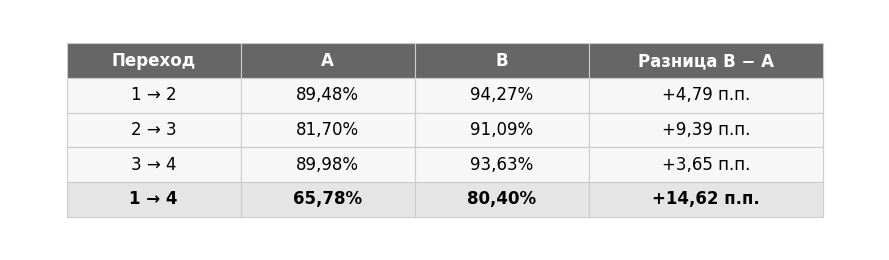

In [76]:
import matplotlib.pyplot as plt

data = [
    ["1 → 2", "89,48%", "94,27%", "+4,79 п.п."],
    ["2 → 3", "81,70%", "91,09%", "+9,39 п.п."],
    ["3 → 4", "89,98%", "93,63%", "+3,65 п.п."],
    ["1 → 4", "65,78%", "80,40%", "+14,62 п.п."]
]

columns = ["Переход", "A", "B", "Разница B − A"]

fig, ax = plt.subplots(figsize=(9, 2.7))
ax.axis("off")

table = ax.table(
    cellText=data,
    colLabels=columns,
    cellLoc="center",
    colLoc="center",
    loc="center",
    colWidths=[0.20, 0.20, 0.20, 0.27]
)

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1, 1.8)

# Оформление
for (row, col), cell in table.get_celld().items():

    # Шапка
    if row == 0:
        cell.set_facecolor("#666666")
        cell.set_text_props(color="white", weight="bold")

    # Последняя строка — ключевая метрика
    elif row == 4:
        cell.set_facecolor("#E5E5E5")
        cell.set_text_props(weight="bold")

    # Остальные строки
    else:
        cell.set_facecolor("#F7F7F7")

    cell.set_edgecolor("#CCCCCC")
    cell.set_linewidth(0.8)

plt.tight_layout()

plt.savefig(
    "images/funnel_table.png",
    dpi=300,
    bbox_inches="tight",
    transparent=False
)

plt.show()